# Comparing the four MI selection variants

Runs all four `MutualInfoSelection` variants on a random subset of `n_sub` proteins from `data/processed/seen.csv` and produces diagnostics:

1. Spearman correlation of raw p-values across methods
2. Scatter plots of $-\log_{10}(p)$ vs Method 1 (the exact reference)
3. Significant set overlap (Jaccard + intersection counts)
4. Tail behaviour: where pooled / GPD methods diverge from Method 1 in the upper-right of the scatter

Each method may use a different `n_permutations` since Methods 2--4 are designed to need fewer permutations than Method 1, and Method 4 fewer still.

In [3]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

sys.path.append(str(Path.cwd().parent))

from src.selection import MutualInfoSelection

## Configuration

Edit `n_sub` and the per-method permutation budgets here. Method 1's `max_permutations` defaults to $\lceil h \cdot p / \alpha \rceil$ so its resolution floor reaches the BH cutoff; for a quick run you can shrink it.

In [4]:
DATA_PATH = Path('..') / 'data' / 'processed' / 'cohort.parquet'

n_sub = 1000
q_threshold = 0.05
n_jobs = -1
subset_seed = 0
method_seed = 42

method_configs = {
    'adaptive':         dict(hits=5, max_permutations=int(np.ceil(5 * n_sub / q_threshold))),
    #'per_feature_gpd':  dict(n_permutations=2000, tail_quantile=0.90),
    #'pooled':           dict(n_permutations=1000),
    #'pooled_gpd':       dict(n_permutations=500,  tail_quantile=0.95),
}

for cfg in method_configs.values():
    cfg.setdefault('q_threshold', q_threshold)
    cfg.setdefault('n_jobs', n_jobs)

method_configs

{'adaptive': {'hits': 5,
  'max_permutations': 100000,
  'q_threshold': 0.05,
  'n_jobs': -1}}

## Load data and sample a protein subset

In [5]:
from sklearn.feature_selection import mutual_info_classif

In [8]:
data_df = pd.read_parquet(DATA_PATH)
protein_cols = [c for c in data_df.columns if c.startswith('seq.')]
y_full = data_df['y'].astype(int).to_numpy()
X_full = data_df[protein_cols].to_numpy(dtype=float)
print(f'Full data: X={X_full.shape}, y mean={y_full.mean():.3f}, n_proteins={len(protein_cols)}')

rng = np.random.default_rng(subset_seed)
#subset_idx = np.sort(rng.choice(X_full.shape[1], size=n_sub, replace=False))
mi_obs = mutual_info_classif(X_full, y_full, random_state=method_seed, n_jobs=-1)
subset_idx = np.argsort(mi_obs)[-n_sub:]

X = X_full[:, subset_idx]
y = y_full
subset_proteins = np.asarray(protein_cols)[subset_idx]
print(f'Subset: X={X.shape}')

Full data: X=(408, 10776), y mean=0.159, n_proteins=10776
Subset: X=(408, 1000)


## Run all four variants

Each selector exposes `p_values_` after `select(...)` (in the original feature order).

In [ ]:
results = {}
for variant, cfg in method_configs.items():
    sel = MutualInfoSelection(variant=variant, **cfg)
    sel.set_split_seed(method_seed)
    t0 = time.perf_counter()
    ranked, scores, q_value, sig = sel.select(X, y)
    elapsed = time.perf_counter() - t0
    sig_mask = np.zeros(n_sub, dtype=bool)
    sig_mask[ranked[sig]] = True
    results[variant] = {
        'p_values': sel.p_values_.copy(),
        'significant_mask': sig_mask,
        'time_s': elapsed,
        'config': cfg,
    }
    print(f'{variant:18s} time={elapsed:7.2f}s  n_significant={int(sig_mask.sum())}')

p_df = pd.DataFrame({v: r['p_values'] for v, r in results.items()})

In [35]:
scores

array([0.05168813, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05283848, 0.05283848, 0.05283848, 0.05283848,
       0.05283848, 0.05571155, 0.05571155, 0.05571155, 0.05571155,
       0.05571155, 0.05571155, 0.05571155, 0.05571155, 0.05571155,
       0.05571155, 0.05571155, 0.05571155, 0.05571155, 0.0559009 ,
       0.0559009 , 0.0559009 , 0.0559009 , 0.0559009 , 0.0565355 ,
       0.0591408 , 0.0591408 , 0.0591408 , 0.0591408 , 0.06183527,
       0.06230064, 0.06400246, 0.0649064 , 0.0649064 , 0.0649064 ,
       0.0649064 , 0.0649064 , 0.0649064 , 0.0649064 , 0.06529

## Diagnostic 1 — Spearman correlation of raw p-values

In [ ]:
variants = list(results)
rho = pd.DataFrame(index=variants, columns=variants, dtype=float)
for a in variants:
    for b in variants:
        rho.loc[a, b] = spearmanr(results[a]['p_values'], results[b]['p_values']).statistic
rho.round(4)

,adaptive,per_feature_gpd,pooled,pooled_gpd
adaptive,1.0000,0.9614,0.9010,0.8976
per_feature_gpd,0.9614,1.0000,0.9382,0.9361
pooled,0.9010,0.9382,1.0000,0.9614
pooled_gpd,0.8976,0.9361,0.9614,1.0000


## Diagnostic 2 — Scatter of $-\log_{10}(p)$ vs Method 1

Method 1 is the exact reference. Points on the diagonal agree; deviations in the upper-right indicate tail miscalibration.

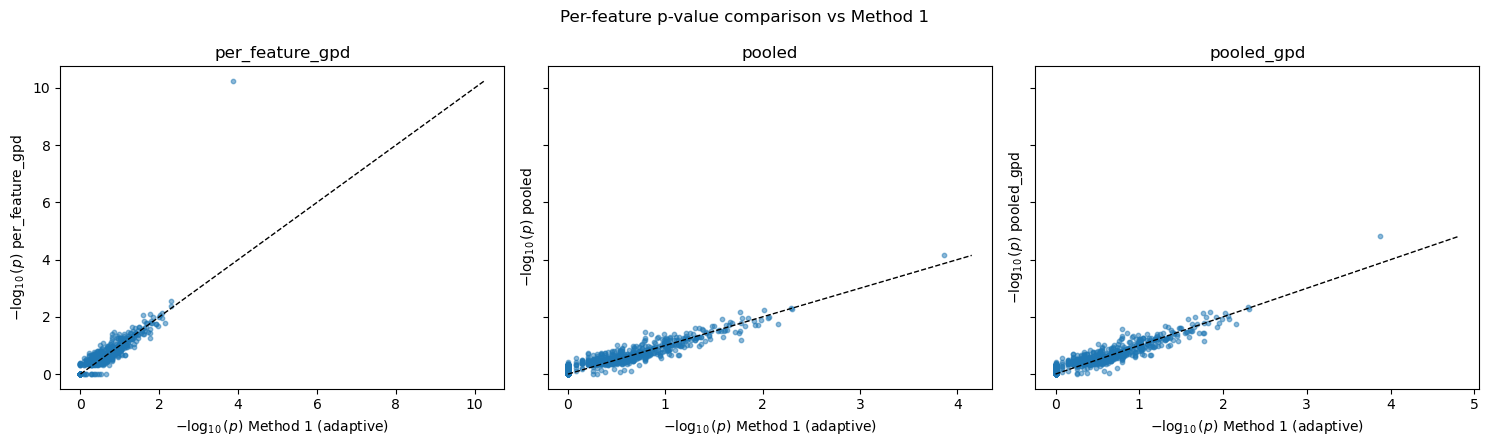

In [ ]:
EPS = 1e-300
neg_log = -np.log10(p_df.clip(lower=EPS))
ref = neg_log['adaptive']
others = [v for v in variants if v != 'adaptive']

fig, axes = plt.subplots(1, len(others), figsize=(5 * len(others), 4.5), sharey=True)
if len(others) == 1:
    axes = [axes]

for ax, v in zip(axes, others):
    ax.scatter(ref, neg_log[v], s=10, alpha=0.5)
    lim = float(max(ref.max(), neg_log[v].max()))
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_xlabel(r'$-\log_{10}(p)$ Method 1 (adaptive)')
    ax.set_ylabel(rf'$-\log_{{10}}(p)$ {v}')
    ax.set_title(v)
fig.suptitle('Per-feature p-value comparison vs Method 1')
fig.tight_layout()
plt.show()

## Diagnostic 3 — Significant set overlap (BH @ q_threshold)

In [ ]:
sig_sets = {v: set(np.where(r['significant_mask'])[0]) for v, r in results.items()}
sizes = pd.Series({v: len(s) for v, s in sig_sets.items()}, name='n_significant')

jaccard = pd.DataFrame(index=variants, columns=variants, dtype=float)
intersect = pd.DataFrame(index=variants, columns=variants, dtype=int)
for a in variants:
    for b in variants:
        sa, sb = sig_sets[a], sig_sets[b]
        inter = len(sa & sb)
        union = len(sa | sb) or 1
        jaccard.loc[a, b] = inter / union
        intersect.loc[a, b] = inter

print('Significant counts:')
print(sizes)
print('\nPairwise intersections:')
print(intersect)
print('\nPairwise Jaccard:')
print(jaccard.round(3))

Significant counts:
adaptive           0
per_feature_gpd    1
pooled             0
pooled_gpd         1
Name: n_significant, dtype: int64

Pairwise intersections:
                 adaptive  per_feature_gpd  pooled  pooled_gpd
adaptive              0.0              0.0     0.0         0.0
per_feature_gpd       0.0              1.0     0.0         1.0
pooled                0.0              0.0     0.0         0.0
pooled_gpd            0.0              1.0     0.0         1.0

Pairwise Jaccard:
                 adaptive  per_feature_gpd  pooled  pooled_gpd
adaptive              0.0              0.0     0.0         0.0
per_feature_gpd       0.0              1.0     0.0         1.0
pooled                0.0              0.0     0.0         0.0
pooled_gpd            0.0              1.0     0.0         1.0


## Diagnostic 4 — GPD tail behaviour

Restrict to the most extreme features under Method 1 and check whether each other method's $-\log_{10}(p)$ lies systematically above (anti-conservative) or below (conservative) the diagonal.

In [ ]:
tail_quantile = 0.95
tail_cut = ref.quantile(tail_quantile)
tail_mask = ref >= tail_cut
print(f'Tail definition: -log10(p) >= {tail_cut:.3f} (top {(1 - tail_quantile) * 100:.0f}% by Method 1), n={int(tail_mask.sum())}')

tail_summary = []
for v in others:
    diff = neg_log.loc[tail_mask, v] - ref[tail_mask]
    tail_summary.append({
        'method': v,
        'mean_diff': diff.mean(),
        'median_diff': diff.median(),
        'frac_above_diag': (diff > 0).mean(),
        'max_over': diff.max(),
        'max_under': diff.min(),
    })
tail_df = pd.DataFrame(tail_summary).set_index('method')
tail_df.round(3)

Tail definition: -log10(p) >= 1.315 (top 5% by Method 1), n=50


,mean_diff,median_diff,frac_above_diag,max_over,max_under
method,,,,,
per_feature_gpd,0.096,-0.007,0.5,6.375,-0.525
pooled,-0.040,-0.057,0.4,0.404,-0.567
pooled_gpd,-0.027,-0.044,0.4,0.951,-0.601


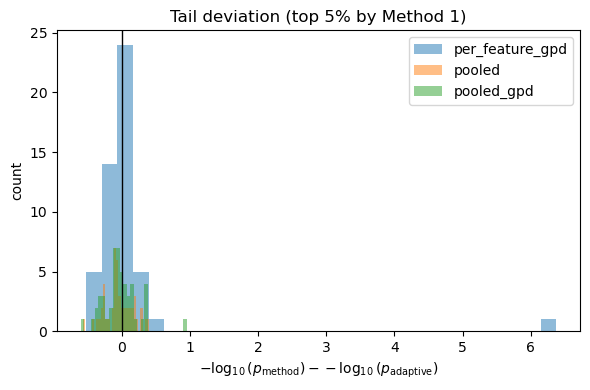

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for v in others:
    diff = neg_log.loc[tail_mask, v] - ref[tail_mask]
    ax.hist(diff, bins=30, alpha=0.5, label=v)
ax.axvline(0, color='k', lw=1)
ax.set_xlabel(r'$-\log_{10}(p_{\mathrm{method}}) - -\log_{10}(p_{\mathrm{adaptive}})$')
ax.set_ylabel('count')
ax.set_title(f'Tail deviation (top {int((1 - tail_quantile) * 100)}% by Method 1)')
ax.legend()
fig.tight_layout()
plt.show()